In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import logging
logging.basicConfig(level=logging.INFO)

## Simulating ZTF SN Ia
This notebook simulates SN Ia light curves with realistic cadence, rate, parameter distributions, etc

In [3]:
quick_test = False
NSIM = 3000
RANDSEED = 1011

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Circle
from scipy.interpolate import interp1d
import pandas as pd
import sncosmo
from scipy import stats
from scipy.special import expit
from nested_pandas import read_parquet
from joblib import Parallel, delayed
import cloudpickle as pickle
from regions import RectangleSkyRegion
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.time import Time
import inspect
from IPython.display import display, Markdown

from lightcurvelynx.obstable.ztf_obstable import ZTFObsTable
from lightcurvelynx.astro_utils.passbands import PassbandGroup
from lightcurvelynx.astro_utils.pzflow_node import PZFlowNode
from lightcurvelynx.astro_utils.snia_utils import (
    DistModFromRedshift,
    HostmassX1Func,
    X0FromDistMod,
    num_snia_per_redshift_bin,
    SNCoordGivenPhysicalSep,
    snia_volumetric_rates,
)
from lightcurvelynx.math_nodes.scipy_random import SamplePDF
from lightcurvelynx.math_nodes.np_random import NumpyRandomFunc
from lightcurvelynx.simulate import simulate_lightcurves
from lightcurvelynx.models.sncosmo_models import SncosmoWrapperModel
from lightcurvelynx.models.snia_host import SNIaHost
from lightcurvelynx.utils.plotting import plot_lightcurves
from lightcurvelynx.math_nodes.ra_dec_sampler import ObsTableUniformRADECSampler
from lightcurvelynx.astro_utils.dustmap import DustmapWrapper,SFDMap
from lightcurvelynx.effects.extinction import ExtinctionEffect
from lightcurvelynx.astro_utils.mag_flux import mag2flux,flux2mag
from lightcurvelynx.astro_utils.detector_footprint import DetectorFootprint
from lightcurvelynx.utils.extrapolate import LinearDecay,ZeroPadding

from lightcurvelynx import _LIGHTCURVELYNX_BASE_DATA_DIR

from lightcurvelynx.validation.lcfit import fit_single_lc

from utils.plotting_utils import plot_coverage_map
from utils.analysis_utils import lc_quality_cuts, spec_selection_func

from ztf_snia_sim_params import SIM_PARAMS

INFO:numexpr.utils:NumExpr defaulting to 10 threads.


In [5]:
RNG = np.random.default_rng(RANDSEED)

In [6]:
# load and define constants that are used throughout the simulations
H0 = SIM_PARAMS["H0"]
OMEGA_M = SIM_PARAMS["Omega_m"]
ALPHA = SIM_PARAMS["alpha"]
BETA = SIM_PARAMS["beta"]
ZMIN = SIM_PARAMS["zmin"]
ZMAX = SIM_PARAMS["zmax"]
MAGABS = SIM_PARAMS["mag_abs"]
SIGMA_MAGABS = SIM_PARAMS["sigma_mag_abs"]

ZP_ERR_MAG = 0.002

In [7]:
globalhostdata = pd.read_csv('ztfsniadr2/tables/globalhost_data.csv')
localhostdata = pd.read_csv('ztfsniadr2/tables/localhost_data.csv')
sndata = pd.read_csv('ztfsniadr2/tables/snia_data.csv')
data = pd.merge(sndata,globalhostdata,on='ztfname')

In [8]:
lcdata = read_parquet('data/ztfsniadr2.parquet')

In [9]:
%%time

obs_log = pd.read_parquet('data/ztf_observing_log_combined_w_metadata.parquet')
colmap = {"ra":"ra",
          "dec":"dec",
          "time":"mjd",
          "zp":"zp_nJy",
          "filter":"filter",
          "sky":"sky_adu",
         }

#ztf ccd size 6144 × 6160 pixel * 16
pixel_scale = 1.01 #arcsec/pixel
center = SkyCoord(ra=0.0, dec=0.0, unit="deg", frame="icrs")
rect_region = RectangleSkyRegion(center=center, width=4*6144.* pixel_scale * u.arcsec, 
                                 height=4*6160.* pixel_scale * u.arcsec, angle=0.0 * u.deg)
ztf_fp = DetectorFootprint(rect_region, pixel_scale=pixel_scale)

ztf_obstable = ZTFObsTable(obs_log,colmap=colmap,detector_footprint=ztf_fp)
ztf_obstable.survey_values["zp_err_mag"] = ZP_ERR_MAG

t_min, t_max = ztf_obstable.time_bounds()
print(f"Loaded OpSim with {len(ztf_obstable)} rows and times [{t_min}, {t_max}]")

# #this is slow, so we only do it once, the total ZTF sky coverage given by the obstable is 
# ztf_obstable._table = ztf_obstable._table.drop_duplicates(subset=['ra','dec'])
# sky_coverage = ztf_obstable.estimate_coverage(use_footprint=True)
# print(f"The total sky coverage is {sky_coverage} square degrees")
# sky_coverage = 31981 #deg^2

passband_group = PassbandGroup.from_preset(preset="ZTF", filters=["g", "r", "i"])
print(f"Loaded Passbands: {passband_group}")

INFO:lightcurvelynx.obstable.obs_table:Provided radius 3.868 is smaller than footprint radius 4.871029037867509. Using the footprint radius instead.
INFO:lightcurvelynx.astro_utils.passbands:Loading passbands from preset ZTF


Loaded OpSim with 522192 rows and times [58288.171875, 59273.55859375]
Loaded Passbands: PassbandGroup containing 3 passbands: ZTF_g, ZTF_r, ZTF_i
CPU times: user 656 ms, sys: 115 ms, total: 772 ms
Wall time: 695 ms


In [10]:
t = Time([t_min,t_max], format='mjd', scale='utc')
t.to_datetime()

array([datetime.datetime(2018, 6, 19, 4, 7, 30),
       datetime.datetime(2021, 2, 28, 13, 24, 22, 500000)], dtype=object)

In [11]:
ztf_obstable._table.columns

Index(['time', 'band', 'fieldid', 'fieldra', 'fielddec', 'rcid', 'maglimit',
       'zp_abmag', 'gain', 'expid', 'infobits', 'skynoise', 'filter',
       'exptime', 'fwhm', 'obsdate', 'scibckgnd', 'ra', 'dec', 'maglim',
       'airmass', 'zp', 'sky', 'obsmjd'],
      dtype='object')

In [12]:
# Load the Flow model into a PZFlow node. This gives access to all of the outputs of the
# flow model as attributes of the PZFlowNode.
pz_node = PZFlowNode.from_file("data/ztfsniadr2_host_sn_before_selection_pzflow.pkl",  # filename
    node_label="pznode",
)
radec_node = ObsTableUniformRADECSampler(ztf_obstable, node_label="radec")

# Create a model for the host of the SNIa. The attributes will be sampled via
# the PZFlowNode's model. So each hos instantiation will have its own properties.
# Note: This requires the user to know the output names from the underlying flow model.

rate = lambda z: 2.35e-5 #(2.35 ± 0.24) × 10^4 Gpc^−3 yr^−1 = (2.35 ± 0.24) × 10^4 * 10^-9 Mpc^−3 yr^−1, from ZTF BTS paper Perley et al. 2020

nsn, z = num_snia_per_redshift_bin(ZMIN, ZMAX, 100, H0=H0, Omega_m=OMEGA_M, vol_rate_function=rate)
zpdf = interp1d(z, nsn, bounds_error=False, fill_value=0)

host = SNIaHost(
    ra = radec_node.ra,
    dec = radec_node.dec,
    hostmass=pz_node.mass,
    redshift=SamplePDF(zpdf),
    node_label="host",
)

INFO:2026-01-06 10:24:18,756:jax._src.xla_bridge:812: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/Users/mi/anaconda3/envs/lightcurvelynx/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/Users/mi/anaconda3/envs/lightcurvelynx/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)


In [13]:
distmod_func = DistModFromRedshift(host.redshift, H0=H0, Omega_m=OMEGA_M)

m_abs_func = NumpyRandomFunc("normal", loc=MAGABS, scale=SIGMA_MAGABS)

# we model host-sn separation as an exponential distribution based on Fig 3 of Gupta et al 2016, mean separation = 5kpc
physical_host_sn_sep = NumpyRandomFunc("exponential", scale = 5.)
sncoor_node = SNCoordGivenPhysicalSep(host.ra, host.dec, physical_host_sn_sep, host.redshift, H0=H0, Omega_m=OMEGA_M,node_label='sncoor_node')

x0_func = X0FromDistMod(
    distmod=distmod_func,
    x1=pz_node.x1,
    c=pz_node.c,
    alpha=ALPHA,
    beta=BETA,
    m_abs=m_abs_func,
    node_label="x0_func",
)

sncosmo_modelname = "salt3"
time_extrap_before = ZeroPadding()
time_extrap_after = LinearDecay(decay_width=50.)
wave_extrap_before = ZeroPadding()
wave_extrap_after = ZeroPadding()
source = SncosmoWrapperModel(
    sncosmo_modelname,
    t0=NumpyRandomFunc("uniform", low=t_min, high=t_max),
    x0=x0_func,
    x1=pz_node.x1,
    c=pz_node.c,
    ra=sncoor_node.ra,
    dec=sncoor_node.dec,
    redshift=host.redshift,
    node_label="source",
    time_extrapolation=(time_extrap_before,time_extrap_after),
    wave_extrapolation=(wave_extrap_before,wave_extrap_after),    
)
    
mwextinction = SFDMap(
    ra=source.ra,
    dec=source.dec,
    node_label="mwext",
)

# Create an extinction effect using the EBVs from that dust map.
ext_effect = ExtinctionEffect(extinction_model="F99", frame='observer', ebv=mwextinction, Rv=3.1)
source.add_effect(ext_effect)


INFO:lightcurvelynx.astro_utils.dustmap:SFD dust map data files not found.
Attempting to download from: ('https://github.com/kbarbary/sfddata/archive/master.tar.gz',)
to the directory /Users/mi/Work/lightcurvelynx/lightcurvelynx/data/dustmaps/sfdmap2


In [14]:
# save model and passbands to pickles
data_to_save = (source, passband_group)
with open("results/saved_model_and_passband.pkl", "wb") as file:
    pickle.dump(data_to_save, file)

In [15]:
### Notes:
### ZTF SN Ia DR2 dates: March(April 1) 2018 - December (Dec 31) 2020
### ZTF has square field?
### Data release has 3628 SN Ia in total
### 2667 passed data quality cut
### volume-limited complete sample to z<0.06

In [16]:
%%time
if quick_test:
    nsntotal = NSIM
else:
    survey_length = (t_max - t_min)/365.
    nsntotal, _ = num_snia_per_redshift_bin(ZMIN,ZMAX,1,solid_angle=9.136*survey_length,vol_rate_function=rate)
    print(f"Survey length = {survey_length} years")
print(f"Simulating {int(nsntotal)} SN ...")

# lightcurves = simulate_lightcurves(source, int(nsntotal), ztf_obstable, passband_group, 
#                                   param_cols = ['source.x0','source.x1','source.c','host.hostmass'],
#                                   obstable_save_cols=["infobits","airmass","fwhm","fieldid"])

lightcurves = simulate_lightcurves(
    model=source,
    num_samples=int(nsntotal),
    obstable=ztf_obstable,
    passbands=passband_group,
    param_cols = ['source.x0','source.x1','source.c','host.hostmass','source.ra','source.dec','host.ra','host.dec'],
    obstable_save_cols=["infobits","airmass","fwhm","fieldid"],
    num_jobs=8,
    batch_size=5000,
    rng=RNG,
)

lightcurves

Survey length = 2.6996896404109587 years
Simulating 105272 SN ...


<timed exec>:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
<timed exec>:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
Simulating: 100%|██████████| 5000/5000 [00:39<00:00, 126.67obj/s]


CPU times: user 5.8 s, sys: 29.9 s, total: 35.7 s
Wall time: 5min 50s


id          ra        dec  nobs            t0         z  \
0            0  155.461196  10.812117   411  59093.252822  0.147875   
1            1   74.734716  56.850038  1052  59120.262920  0.150867   
...        ...         ...        ...   ...           ...       ...   
105270  105270  165.224355  20.241161   448  58924.461268  0.162631   
105271  105271  349.249397 -18.252786   313  58450.132580  0.139126   

                                                   params  source_x0  \
0       {'radec.ra': 155.46106007897293, 'radec.dec': ...   0.000190   
1       {'radec.ra': 74.73569220550871, 'radec.dec': 5...   0.000122   
...                                                   ...        ...   
105270  {'radec.ra': 165.2244352878353, 'radec.dec': 2...   0.000039   
105271  {'radec.ra': 349.24938841377474, 'radec.dec': ...   0.000205   

        source_x1  source_c  host_hostmass   source_ra  source_dec  \
0        0.116075  0.005235      10.609704  155.461196   10.812117   
1       -0.476493  0.004102      10.658600   74.734716   56.850038   
...           ...       ...            ...         ...         ...   
105270  -0.618050  0.486509      10.719107  165.224355   20.241161   
105271  -0.146277 -0.097100       8.881440  349.249397  -18.252786   

           host_ra   host_dec  \
0       155.461060  10.812113   
1        74.735692  56.850426   
...            ...        ...   
105270  165.224435  20.241033   
105271  349.249388 -18.252806   

                                               lightcurve  
0       [{mjd: 58290.195312, filter: 'g', flux: -9155....  
1       [{mjd: 58307.480469, filter: 'g', flux: 3418.6...  
...                                                   ...  
105270  [{mjd: 58290.195312, filter: 'g', flux: -972.1...  
105271  [{mjd: 58289.4375, filter: 'g', flux: 2199.347...  

[105272 rows x 16 columns]

In [17]:
lightcurves['params'][0].keys()

dict_keys(['radec.ra', 'radec.dec', 'host.ra', 'host.dec', 'host.redshift', 'host.t0', 'host.distance', 'host.hostmass', 'SamplePDF:_rvs_4.function_node_result', 'pznode.mass', 'pznode.x1', 'pznode.c', 'sncoor_node.host_ra', 'sncoor_node.host_dec', 'sncoor_node.physical_sep_kpc', 'sncoor_node.redshift', 'sncoor_node.ra', 'sncoor_node.dec', 'NumpyRandomFunc:exponential_6.scale', 'NumpyRandomFunc:exponential_6.function_node_result', 'source.ra', 'source.dec', 'source.redshift', 'source.t0', 'source.distance', 'source.x0', 'source.x1', 'source.c', 'source.Rv', 'source.ebv', 'NumpyRandomFunc:uniform_7.low', 'NumpyRandomFunc:uniform_7.high', 'NumpyRandomFunc:uniform_7.function_node_result', 'DistModFromRedshift:_distmod_from_redshift_9.redshift', 'DistModFromRedshift:_distmod_from_redshift_9.function_node_result', 'x0_func.distmod', 'x0_func.x1', 'x0_func.c', 'x0_func.alpha', 'x0_func.beta', 'x0_func.m_abs', 'x0_func.function_node_result', 'NumpyRandomFunc:normal_10.loc', 'NumpyRandomFunc:n

In [18]:
lightcurves.lightcurve.isna().sum()

np.int64(0)

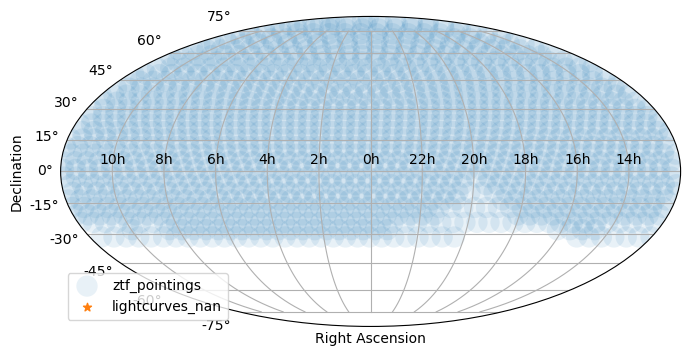

In [19]:
plot_coverage_map(ztf_obstable,lightcurves,plot_na_location=True,plot_all_location=False)

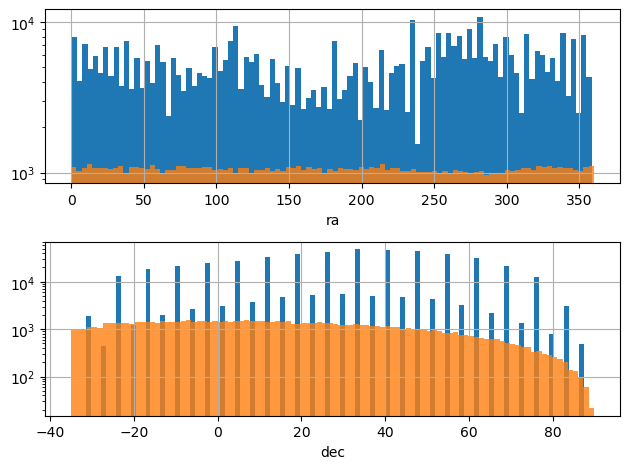

In [20]:
idx = lightcurves.lightcurve.isna()

plt.subplot(2,1,1)
ztf_obstable._table.ra.hist(bins=100,density=False)
lightcurves.ra.hist(bins=100,alpha=0.8,density=False)
lightcurves.loc[idx].ra.hist(bins=100)
plt.yscale('log')
plt.xlabel('ra')

plt.subplot(2,1,2)
ztf_obstable._table.dec.hist(bins=100,density=False)
lightcurves.dec.hist(bins=100,alpha=0.8,density=False)
lightcurves.loc[idx].dec.hist(bins=100)
plt.yscale('log')
plt.xlabel('dec')

plt.tight_layout()

In [21]:
# calculate detection flag
lightcurves = lightcurves.dropna(subset=['lightcurve'])

print("Before applying detection: nsn=", len(lightcurves))
lightcurves['lightcurve.snr'] = lightcurves['lightcurve.flux']/lightcurves['lightcurve.fluxerr']
detection_snr_thres = 5.
lightcurves['lightcurve.detection_flag'] = lightcurves['lightcurve.snr'] > detection_snr_thres

# drop saturation
lightcurves_after_drop_sat = lightcurves.query("lightcurve.is_saturated==False").dropna(subset=['lightcurve'])
print("After droppoing saturation: nsn=", len(lightcurves_after_drop_sat))

lightcurves_after_detection = lightcurves_after_drop_sat.query("lightcurve.detection_flag == True").dropna(subset=['lightcurve'])
print("After applying detection: nsn=", len(lightcurves_after_detection))

Before applying detection: nsn= 105272


/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:1349: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)


After droppoing saturation: nsn= 105272


/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:1349: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)


After applying detection: nsn= 51482


ZTF Selection Function (Fig 4 of ZTF DR2 Overview paper https://arxiv.org/pdf/2409.04346)
<img src="figs/ztf_selection_function.png" width="800" height="400">
<img src="figs/ztf_selection_function_formulism.png" width="800" height="400">

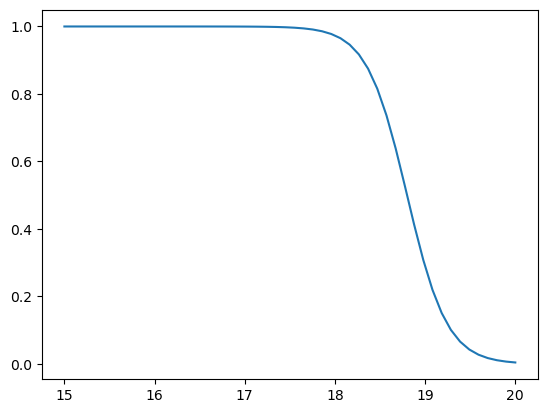

In [22]:
m = np.linspace(15,20,50)
m0=18.8
s=4.5
p = np.power(1. + np.exp((m - m0)*s), -1)
plt.plot(m,p)

In [23]:
# The selection function is defined as below.
display(Markdown(f"```python\n{inspect.getsource(spec_selection_func)}\n```"))

```python
def spec_selection_func(flux,m0=18.8,s=4.5):
    m = flux2mag(np.max(flux))
    p = np.power(1. + np.exp((m - m0)*s), -1)
    p0 = np.random.uniform(0,1)
    if p0 < p:
        return {"pass_spec_selection":True}
    else:
        return {"pass_spec_selection":False}

```

In [24]:
# apply the above selection function

pass_selection = lightcurves_after_detection.reduce(spec_selection_func,"lightcurve.flux")
idx = pass_selection.query("pass_spec_selection == True").index
lightcurves_after_spec_selection = lightcurves_after_detection.loc[idx]
print("After spectroscopic selection: nsn=", len(lightcurves_after_spec_selection))

lightcurves["pass_spec_selection"] = False
lightcurves.loc[idx,"pass_spec_selection"] = True

/var/folders/zs/zxl3t6ks12zg2l3dp9qn1rkr0000gn/T/ipykernel_10607/1110383504.py:3: DeprecationWarning: Call to deprecated method reduce. (`reduce` will be removed in version 0.7.0, use `map_rows` instead.) -- Deprecated since version 0.6.0.
  pass_selection = lightcurves_after_detection.reduce(spec_selection_func,"lightcurve.flux")


After spectroscopic selection: nsn= 4733


In [25]:
## ZTF SN DR2 selection cuts
# Start 3795
# No ZTF light curve -17 = 3778
# No spectra -110 = 3668
# No confirmed Ia type from spectra -40 = 3628
# Good sampling (7 different phases, 2 before, 2 after peak, 2 bands) = 2960, peak based on a salt2 fit
# SALT2 cuts = 2667

#### ZTF SN DR2 selection cuts
<img src="figs/ztf_selection_Table1_Rigault2024.png" width="800" height="400">

#### Good sampling cuts
<img src="figs/good_sample_cut.png" width="600" height="200">
<img src="figs/good_sample_cut2.png" width="600" height="200">

In [26]:
# The lc_quality_cuts is defined as below
display(Markdown(f"```python\n{inspect.getsource(lc_quality_cuts)}\n```"))

```python
def lc_quality_cuts(flux,mjd,filter,z,n_phases=7, n_before_peak=2, n_after_peak=2, n_bands=2):
    peak_idx = np.argmax(flux)
    phases = np.floor((mjd - mjd[peak_idx])/(1. + z))
    unique_phases,unique_idx = np.unique(phases,return_index=True)
    good_idx = (unique_phases >= -10) & (unique_phases<=40)
    pass_cut = len(unique_phases[good_idx]) >= n_phases
    flux_new = flux[unique_idx][good_idx]
    peak_idx_new = np.argmax(flux_new)
    pass_cut &= (peak_idx_new >= n_before_peak - 1) & (len(flux_new) - peak_idx_new >= n_after_peak - 1)
    pass_cut &= len(np.unique(filter[unique_idx][good_idx])) >= n_bands
    return {"pass_quality_cuts": pass_cut}

```

In [27]:
pass_quality_cut = lightcurves_after_spec_selection.reduce(lc_quality_cuts,"lightcurve.flux",
                                                           "lightcurve.mjd","lightcurve.filter","z")
idx = pass_quality_cut.query("pass_quality_cuts == True").index
lightcurves_after_quality_cut = lightcurves_after_spec_selection.loc[idx]
print("After quality cuts: nsn=", len(lightcurves_after_quality_cut))

lightcurves["pass_quality_cuts"] = False
lightcurves.loc[idx,"pass_quality_cuts"] = True

After quality cuts: nsn= 3665


/var/folders/zs/zxl3t6ks12zg2l3dp9qn1rkr0000gn/T/ipykernel_10607/2223098793.py:1: DeprecationWarning: Call to deprecated method reduce. (`reduce` will be removed in version 0.7.0, use `map_rows` instead.) -- Deprecated since version 0.6.0.
  pass_quality_cut = lightcurves_after_spec_selection.reduce(lc_quality_cuts,"lightcurve.flux",


In [28]:
lightcurves.head()

id          ra        dec  nobs            t0         z  \
0   0  155.461196  10.812117   411  59093.252822  0.147875   
1   1   74.734716  56.850038  1052  59120.262920  0.150867   
2   2  270.453856   7.358522   678  59171.744427  0.153315   
3   3  175.237605  27.749533   792  58664.600741  0.073493   
4   4   72.007917   4.181406   565  58804.928513  0.153977   

                                              params  source_x0  source_x1  \
0  {'radec.ra': 155.46106007897293, 'radec.dec': ...   0.000190   0.116075   
1  {'radec.ra': 74.73569220550871, 'radec.dec': 5...   0.000122  -0.476493   
2  {'radec.ra': 270.4538842552645, 'radec.dec': 7...   0.000039  -0.184232   
3  {'radec.ra': 175.2380464028913, 'radec.dec': 2...   0.000937   1.629252   
4  {'radec.ra': 72.00800179801814, 'radec.dec': 4...   0.000141  -0.492835   

   source_c  host_hostmass   source_ra  source_dec     host_ra   host_dec  \
0  0.005235      10.609704  155.461196   10.812117  155.461060  10.812113   
1  0.004102      10.658600   74.734716   56.850038   74.735692  56.850426   
2  0.426158      10.912789  270.453856    7.358522  270.453884   7.358718   
3  0.020544       8.163163  175.237605   27.749533  175.238046  27.750762   
4 -0.014910       9.527334   72.007917    4.181406   72.008002   4.181293   

                                          lightcurve  pass_spec_selection  \
0  [{mjd: 58290.195312, filter: 'g', flux: -9155....                False   
1  [{mjd: 58307.480469, filter: 'g', flux: 3418.6...                False   
2  [{mjd: 58288.3125, filter: 'r', flux: -674.090...                False   
3  [{mjd: 58289.175781, filter: 'g', flux: 3337.4...                 True   
4  [{mjd: 58334.480469, filter: 'g', flux: -3527....                 True   

   pass_quality_cuts  
0              False  
1              False  
2              False  
3               True  
4              False

In [29]:
#saving to parquet file
lightcurves.to_parquet("results/lightcurves.parquet")

In [30]:
def fit_single_lc_w_cond(lc,
                         bounds={"x1": (-5,5),
                                 "c": (-0.4,1),},
                         phase_range=(-10,40),
                         modelcov=False):
    return fit_single_lc(lc,mpbounds=bounds,phase_range=phase_range,modelcov=modelcov)

In [31]:
res = fit_single_lc_w_cond(lightcurves_after_quality_cut.iloc[0])
res

INFO:lightcurvelynx.validation.lcfit:fitting 3, z=0.0734930780828671, mwebv=0.019528090051120335.


success             1.0
ncall              70.0
                   ... 
mwebv_mwebv_cov     0.0
id                  3.0
Length: 53, dtype: float64

In [32]:
lc_to_fit = lightcurves_after_quality_cut.iloc[0:]

In [33]:
# %%time
# result_df0 = lc_to_fit.apply(fit_single_lc,axis=1)

In [34]:
%%time
results = Parallel(n_jobs=10)(delayed(fit_single_lc_w_cond)(row) for _index, row in lc_to_fit.iterrows())
result_df = pd.DataFrame(results)

CPU times: user 7.25 s, sys: 968 ms, total: 8.22 s
Wall time: 1min 55s


In [35]:
result_df = result_df.set_index('id')

In [36]:
result_df.dropna()

,success,ncall,chisq,ndof,z,z_err,t0,t0_err,x0,x0_err,...,c_x0_cov,c_x1_cov,c_c_cov,c_mwebv_cov,mwebv_z_cov,mwebv_t0_cov,mwebv_x0_cov,mwebv_x1_cov,mwebv_c_cov,mwebv_mwebv_cov
id,,,,,,,,,,,,,,,,,,,,,
3.0,1.0,70.0,12.497428,10.0,0.073493,0.0,58664.650878,0.145450,0.000935,0.000010,...,-6.800375e-08,1.812459e-04,0.000118,0.0,0.0,0.0,0.0,0.0,0.0,0.0
39.0,1.0,81.0,50.780411,34.0,0.024911,0.0,59014.857296,0.046102,0.004214,0.000027,...,-1.298823e-07,8.586349e-07,0.000027,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105245.0,1.0,91.0,18.881266,18.0,0.072784,0.0,58999.374825,0.509532,0.000778,0.000013,...,-1.470119e-07,-8.833501e-04,0.000273,0.0,0.0,0.0,0.0,0.0,0.0,0.0
105264.0,1.0,85.0,166.688241,170.0,0.019698,0.0,58941.962657,0.018898,0.012757,0.000024,...,-2.465281e-08,4.054099e-06,0.000001,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [37]:
result_df.to_csv('results/salt3fit_results.csv')